# Finalize Split

Compare **standard** (stratified random) vs **topic-hard** (topic-clustered) splits across three classifiers:

| Model | Type |
|---|---|
| LogReg | TF-IDF + Logistic Regression |
| BiLSTM | RNN sequence classifier |
| Transformer | DistilBERT fine-tuned |

We train each model on both splits, collect dev/test metrics, and determine which split yields better (or more challenging) generalization.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import pandas as pd
from data.splits import load_cleaned_data, get_all_splits

df = load_cleaned_data()
print(f"Dataset: {len(df):,} rows, label distribution:\n{df['label'].value_counts().to_string()}")

SPLITS = ["standard", "topic_hard"]
split_frames = {}
for name in SPLITS:
    train_df, dev_df, test_df = get_all_splits(df, split=name)
    split_frames[name] = {"train": train_df, "dev": dev_df, "test": test_df}
    print(f"\n--- {name} ---")
    for part, part_df in [("train", train_df), ("dev", dev_df), ("test", test_df)]:
        pos_rate = part_df["label"].mean()
        print(f"  {part:5s}: {len(part_df):>6,} rows  (label=1: {pos_rate:.3f})")

Dataset: 28,503 rows, label distribution:
label
0    14951
1    13552

--- standard ---
  train: 22,802 rows  (label=1: 0.475)
  dev  :  2,850 rows  (label=1: 0.475)
  test :  2,851 rows  (label=1: 0.476)

--- topic_hard ---
  train: 22,875 rows  (label=1: 0.485)
  dev  :  2,774 rows  (label=1: 0.412)
  test :  2,854 rows  (label=1: 0.460)


## 1. Train all classifiers on both splits

Each classifier is trained twice (once per split) and artifacts are saved to separate directories so they don't overwrite each other.


In [2]:
from classifiers import CLASSIFIERS

PROJECT_ROOT = Path("..").resolve()
ARTIFACT_BASE = PROJECT_ROOT / "artifacts" / "classifiers"

all_results: list[dict] = []

for split_name in SPLITS:
    for model_name, train_fn in CLASSIFIERS.items():
        output_dir = ARTIFACT_BASE / model_name / split_name
        print(f"\n{'='*60}")
        print(f"  Training {model_name.upper()} on '{split_name}' split")
        print(f"  Output -> {output_dir}")
        print(f"{'='*60}")

        metrics = train_fn(split=split_name, output_dir=output_dir)

        for eval_set in ["dev", "test"]:
            row = {
                "split": split_name,
                "model": model_name,
                "eval_set": eval_set,
                **metrics[eval_set],
            }
            all_results.append(row)

results_df = pd.DataFrame(all_results)
print("\nAll training runs complete.")
results_df


  Training LOGREG on 'standard' split
  Output -> E:\CS4248_Project\artifacts\classifiers\logreg\standard
Saved model -> E:\CS4248_Project\artifacts\classifiers\logreg\standard\model.joblib
Saved metrics -> E:\CS4248_Project\artifacts\classifiers\logreg\standard\metrics.json
{
  "dev": {
    "accuracy": 0.8557894736842105,
    "precision": 0.826417704011065,
    "recall": 0.8819188191881919,
    "f1": 0.8532666904676901,
    "roc_auc": 0.9295432499475498
  },
  "test": {
    "accuracy": 0.8411083830235005,
    "precision": 0.8155136268343816,
    "recall": 0.8606194690265486,
    "f1": 0.83745963401507,
    "roc_auc": 0.9169818766586754
  },
  "config": {
    "model_type": "logreg",
    "split": "standard",
    "text_col": "text",
    "max_features": 50000,
    "c_value": 1.0
  }
}

  Training RNN on 'standard' split
  Output -> E:\CS4248_Project\artifacts\classifiers\rnn\standard


Epoch 1/3: 100%|██████████| 357/357 [00:13<00:00, 26.58it/s]


Epoch 1: loss=0.4786, dev_f1=0.8164


Epoch 2/3: 100%|██████████| 357/357 [00:13<00:00, 27.16it/s]


Epoch 2: loss=0.3161, dev_f1=0.8358


...

Epoch 3/3: 100%|██████████| 358/358 [00:11<00:00, 30.69it/s]


Epoch 3: loss=0.1992, dev_f1=0.8010
Saved model -> E:\CS4248_Project\artifacts\classifiers\rnn\topic_hard\model.pt
Saved metrics -> E:\CS4248_Project\artifacts\classifiers\rnn\topic_hard\metrics.json
{
  "dev": {
    "accuracy": 0.8287671232876712,
    "precision": 0.7652656621728786,
    "recall": 0.8435314685314685,
    "f1": 0.8024948024948025,
    "roc_auc": 0.9100057917542581
  },
  "test": {
    "accuracy": 0.7855641205325858,
    "precision": 0.7397260273972602,
    "recall": 0.823170731707317,
    "f1": 0.7792207792207793,
    "roc_auc": 0.8689906697826706
  },
  "train_config": {
    "split": "topic_hard",
    "epochs": 3,
    "batch_size": 64,
    "lr": 0.001,
    "seed": 42
  }
}

  Training TRANSFORMER on 'topic_hard' split
  Output -> E:\CS4248_Project\artifacts\classifiers\transformer\topic_hard


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 1/1: 100%|██████████| 1430/1430 [23:59<00:00,  1.01s/it]


Epoch 1: loss=0.2782, dev_f1=0.8980
Saved model + tokenizer -> E:\CS4248_Project\artifacts\classifiers\transformer\topic_hard
Saved metrics -> E:\CS4248_Project\artifacts\classifiers\transformer\topic_hard\metrics.json
{
  "dev": {
    "accuracy": 0.916366258111031,
    "precision": 0.9035398230088496,
    "recall": 0.8924825174825175,
    "f1": 0.8979771328056289,
    "roc_auc": 0.9744422755158951
  },
  "test": {
    "accuracy": 0.8973370707778556,
    "precision": 0.8880426504188881,
    "recall": 0.8887195121951219,
    "f1": 0.8883809523809524,
    "roc_auc": 0.9650373880927525
  },
  "train_config": {
    "split": "topic_hard",
    "model_name": "distilbert-base-uncased",
    "text_col": "text",
    "max_length": 64,
    "batch_size": 16,
    "lr": 2e-05,
    "epochs": 1,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "seed": 42
  }
}

All training runs complete.


,split,model,eval_set,accuracy,precision,recall,f1,roc_auc
0,standard,logreg,dev,0.855789,0.826418,0.881919,0.853267,0.929543
1,standard,logreg,test,0.841108,0.815514,0.860619,0.837460,0.916982
2,standard,rnn,dev,0.855439,0.832276,0.871587,0.851478,0.933291
3,standard,rnn,test,0.840407,0.816140,0.857670,0.836390,0.921467
4,standard,transformer,dev,0.918246,0.911894,0.916605,0.914244,0.976678
5,standard,transformer,test,0.922834,0.921365,0.915929,0.918639,0.975242
6,topic_hard,logreg,dev,0.831651,0.781380,0.821678,0.801023,0.913999
7,topic_hard,logreg,test,0.806938,0.770434,0.826220,0.797352,0.886795
8,topic_hard,rnn,dev,0.828767,0.765266,0.843531,0.802495,0.910006
9,topic_hard,rnn,test,0.785564,0.739726,0.823171,0.779221,0.868991


## 2. Side-by-side comparison

Pivot tables so we can compare each metric across splits for every model.

In [3]:
METRICS = ["accuracy", "precision", "recall", "f1", "roc_auc"]

test_df_results = results_df[results_df["eval_set"] == "test"].copy()
dev_df_results = results_df[results_df["eval_set"] == "dev"].copy()

print("=== TEST-SET RESULTS ===\n")
test_pivot = test_df_results.pivot_table(
    index="model", columns="split", values=METRICS,
).round(4)
test_pivot.columns = [f"{metric} ({split})" for metric, split in test_pivot.columns]
display(test_pivot)

print("\n=== DEV-SET RESULTS ===\n")
dev_pivot = dev_df_results.pivot_table(
    index="model", columns="split", values=METRICS,
).round(4)
dev_pivot.columns = [f"{metric} ({split})" for metric, split in dev_pivot.columns]
display(dev_pivot)

=== TEST-SET RESULTS ===



,accuracy (standard),accuracy (topic_hard),f1 (standard),f1 (topic_hard),precision (standard),precision (topic_hard),recall (standard),recall (topic_hard),roc_auc (standard),roc_auc (topic_hard)
model,,,,,,,,,,
logreg,0.8411,0.8069,0.8375,0.7974,0.8155,0.7704,0.8606,0.8262,0.9170,0.8868
rnn,0.8404,0.7856,0.8364,0.7792,0.8161,0.7397,0.8577,0.8232,0.9215,0.8690
transformer,0.9228,0.8973,0.9186,0.8884,0.9214,0.8880,0.9159,0.8887,0.9752,0.9650



=== DEV-SET RESULTS ===



,accuracy (standard),accuracy (topic_hard),f1 (standard),f1 (topic_hard),precision (standard),precision (topic_hard),recall (standard),recall (topic_hard),roc_auc (standard),roc_auc (topic_hard)
model,,,,,,,,,,
logreg,0.8558,0.8317,0.8533,0.8010,0.8264,0.7814,0.8819,0.8217,0.9295,0.9140
rnn,0.8554,0.8288,0.8515,0.8025,0.8323,0.7653,0.8716,0.8435,0.9333,0.9100
transformer,0.9182,0.9164,0.9142,0.8980,0.9119,0.9035,0.9166,0.8925,0.9767,0.9744


## 3. Visualize the comparison

Bar charts grouped by model, showing F1 and accuracy on the test set for each split.

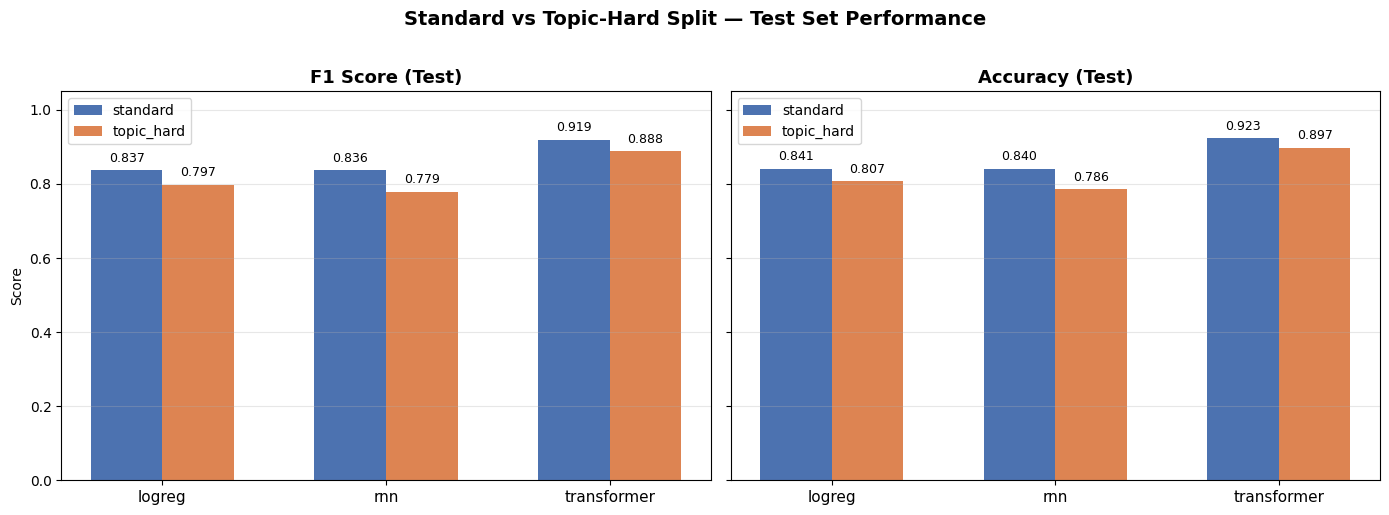

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, metric_col, title in zip(
    axes,
    ["f1", "accuracy"],
    ["F1 Score (Test)", "Accuracy (Test)"],
):
    sub = test_df_results[["model", "split", metric_col]].copy()
    pivot = sub.pivot(index="model", columns="split", values=metric_col)
    pivot = pivot[SPLITS]

    x = np.arange(len(pivot))
    width = 0.32

    bars1 = ax.bar(x - width / 2, pivot["standard"], width, label="standard", color="#4c72b0")
    bars2 = ax.bar(x + width / 2, pivot["topic_hard"], width, label="topic_hard", color="#dd8452")

    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 4), textcoords="offset points",
                        ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Score")
fig.suptitle("Standard vs Topic-Hard Split — Test Set Performance", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4. Performance drop analysis

Compute the delta (standard − topic_hard) for each model and metric on the test set.
A **positive delta** means the model performed better on the standard split (i.e. topic-hard is harder).

In [5]:
std_test = test_df_results[test_df_results["split"] == "standard"].set_index("model")[METRICS]
th_test = test_df_results[test_df_results["split"] == "topic_hard"].set_index("model")[METRICS]

delta = (std_test - th_test).round(4)
delta.columns = [f"Δ {m}" for m in METRICS]
print("Performance delta (standard − topic_hard) on test set:\n")
display(delta)

avg_delta = delta.mean()
print(f"\nAverage drop across models:")
for col, val in avg_delta.items():
    direction = "↓ harder" if val > 0 else "↑ easier"
    print(f"  {col}: {val:+.4f}  ({direction} on topic_hard)")

Performance delta (standard − topic_hard) on test set:



,Δ accuracy,Δ precision,Δ recall,Δ f1,Δ roc_auc
model,,,,,
logreg,0.0342,0.0451,0.0344,0.0401,0.0302
rnn,0.0548,0.0764,0.0345,0.0572,0.0525
transformer,0.0255,0.0333,0.0272,0.0303,0.0102



Average drop across models:
  Δ accuracy: +0.0382  (↓ harder on topic_hard)
  Δ precision: +0.0516  (↓ harder on topic_hard)
  Δ recall: +0.0320  (↓ harder on topic_hard)
  Δ f1: +0.0425  (↓ harder on topic_hard)
  Δ roc_auc: +0.0310  (↓ harder on topic_hard)


## 5. All metrics at a glance (heatmap)

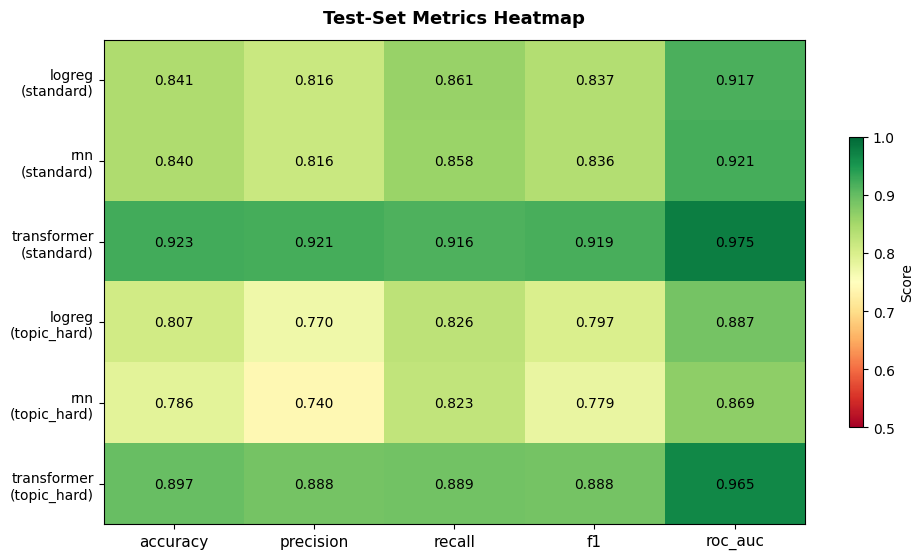

In [6]:
test_wide = test_df_results.copy()
test_wide["label"] = test_wide["model"] + "\n(" + test_wide["split"] + ")"
test_wide = test_wide.set_index("label")[METRICS]

fig, ax = plt.subplots(figsize=(10, len(test_wide) * 0.7 + 1.5))
im = ax.imshow(test_wide.values, cmap="RdYlGn", aspect="auto", vmin=0.5, vmax=1.0)

ax.set_xticks(range(len(METRICS)))
ax.set_xticklabels(METRICS, fontsize=11)
ax.set_yticks(range(len(test_wide)))
ax.set_yticklabels(test_wide.index, fontsize=10)

for i in range(test_wide.shape[0]):
    for j in range(test_wide.shape[1]):
        val = test_wide.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=10,
                color="white" if val < 0.65 else "black")

ax.set_title("Test-Set Metrics Heatmap", fontsize=13, fontweight="bold", pad=12)
fig.colorbar(im, ax=ax, shrink=0.6, label="Score")
plt.tight_layout()
plt.show()

## 6. Verdict

In [7]:
avg_f1_std = std_test["f1"].mean()
avg_f1_th = th_test["f1"].mean()

print("=" * 60)
print("  SPLIT COMPARISON VERDICT  (based on test-set F1)")
print("=" * 60)
print(f"  Average F1 on standard split:   {avg_f1_std:.4f}")
print(f"  Average F1 on topic_hard split: {avg_f1_th:.4f}")
print(f"  Δ F1 (standard − topic_hard):   {avg_f1_std - avg_f1_th:+.4f}")
print()

if avg_f1_std > avg_f1_th + 0.005:
    print("  → Models perform BETTER on the standard split.")
    print("  → The topic-hard split is MORE CHALLENGING,")
    print("    as expected when test topics differ from training topics.")
    print("  → If you want a harder, more realistic evaluation, use topic_hard.")
    print("  → If you want higher headline numbers, use standard.")
elif avg_f1_th > avg_f1_std + 0.005:
    print("  → Models perform BETTER on the topic-hard split.")
    print("  → The standard split may be harder for this dataset,")
    print("    or topic clustering helped create a more balanced evaluation.")
    print("  → Consider using topic_hard as the primary split.")
else:
    print("  → Performance is roughly EQUIVALENT across both splits.")
    print("  → The choice of split may depend on other factors")
    print("    (topic generalization, label balance, etc.).")

print("=" * 60)

  SPLIT COMPARISON VERDICT  (based on test-set F1)
  Average F1 on standard split:   0.8642
  Average F1 on topic_hard split: 0.8217
  Δ F1 (standard − topic_hard):   +0.0425

  → Models perform BETTER on the standard split.
  → The topic-hard split is MORE CHALLENGING,
    as expected when test topics differ from training topics.
  → If you want a harder, more realistic evaluation, use topic_hard.
  → If you want higher headline numbers, use standard.
